### Project name : Saudi Electricity

## objectve :

"To analyze historical electricity consumption data in Saudi Arabia and build two machine learning models:

Regression Model – to predict future electricity consumption (in MWh) based on Year, Region, and Sector.

Classification Model – to classify the consumption Sector (Agricultural, Governmental, Others, etc.) based on Year, Region, and Consumption values.

The goal is to support decision-makers in energy planning and resource allocation across different regions and sectors in Saudi Arabia."


"تحليل بيانات استهلاك الكهرباء التاريخية في السعودية، وبناء نموذجين من نماذج التعلم الآلي:

١. نموذج الانحدار (Regression) – للتنبؤ باستهلاك الكهرباء المستقبلي (بالميغاواط) بناءً على السنة، المنطقة، والقطاع.

٢. نموذج التصنيف (Classification) – لتصنيف القطاع المستهلك (زراعي، حكومي، آخر) بناءً على السنة، المنطقة، وكمية الاستهلاك.

الهدف هو دعم صناع القرار في تخطيط الطاقة وتوزيع الموارد بين مختلف المناطق والقطاعات في المملكة."



## 1 import data

In [1]:
import pandas as pd

df = pd.read_csv("electricity-consumption.csv", sep=";")

## 2 Data Exploration

In [40]:
print(df.head())

   Year    Region        Sector  Consumption  Region_n  Sector_n
0  2005   Western  Governmental    4716438.0         3         2
1  2005  Southern  Governmental    1176250.0         2         2
4  2005   Eastern  Agricultural     475056.0         1         0
5  2005   Western  Agricultural     310849.0         3         0
6  2005   Central        Others    2186793.0         0         4


In [38]:
df.shape

(432, 6)

In [41]:
df.info()

<class 'pandas.DataFrame'>
Index: 432 entries, 0 to 629
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         432 non-null    int64  
 1   Region       432 non-null    str    
 2   Sector       432 non-null    str    
 3   Consumption  432 non-null    float64
 4   Region_n     432 non-null    int32  
 5   Sector_n     432 non-null    int32  
dtypes: float64(1), int32(2), int64(1), str(2)
memory usage: 27.7 KB


In [42]:
df.describe()

,Year,Consumption,Region_n,Sector_n
count,432.000000,4.320000e+02,432.00000,432.000000
mean,2013.500000,1.010411e+07,1.50000,2.500000
std,5.194143,1.239107e+07,1.11933,1.709805
min,2005.000000,5.234200e+04,0.00000,0.000000
25%,2009.000000,1.772544e+06,0.75000,1.000000
50%,2013.500000,5.108794e+06,1.50000,2.500000
75%,2018.000000,1.217205e+07,2.25000,4.000000
max,2022.000000,5.156798e+07,3.00000,5.000000


## 3 Data Cleaning

In [3]:
df.rename(columns={"Electricity Consumption (MWh)":"Consumption"},inplace=True)

In [4]:
df.drop(["Name","Date_Object","Periodicity"],axis=1, inplace=True)

In [5]:
df.isnull()

,Year,Region,Sector,Consumption
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
625,False,False,False,False
626,False,False,False,False
627,False,False,False,False
628,False,False,False,False


What does it do ?

it checks for empty values (NaN)

Result:

True = empty

False = contain a value 

In [43]:
df.isnull().sum()

Year           0
Region         0
Sector         0
Consumption    0
Region_n       0
Sector_n       0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.dtypes

Year             int64
Region             str
Sector             str
Consumption    float64
dtype: object

In [9]:
df["Consumption"] = pd.to_numeric(df["Consumption"], errors="coerce")

In [10]:
df.head()
df.describe()

,Year,Consumption
count,630.00000,6.300000e+02
mean,2013.50000,2.771413e+07
std,5.19225,4.698330e+07
min,2005.00000,5.234200e+04
25%,2009.00000,3.149029e+06
50%,2013.50000,8.757423e+06
75%,2018.00000,3.358940e+07
max,2022.00000,2.987016e+08


In [22]:
df = df[df["Region"] != "Total"]
df = df[df["Sector"] != "Total"]

Region = Total !!

This isn't a real region.

It's best to delete it.

## 4 Data Visualization

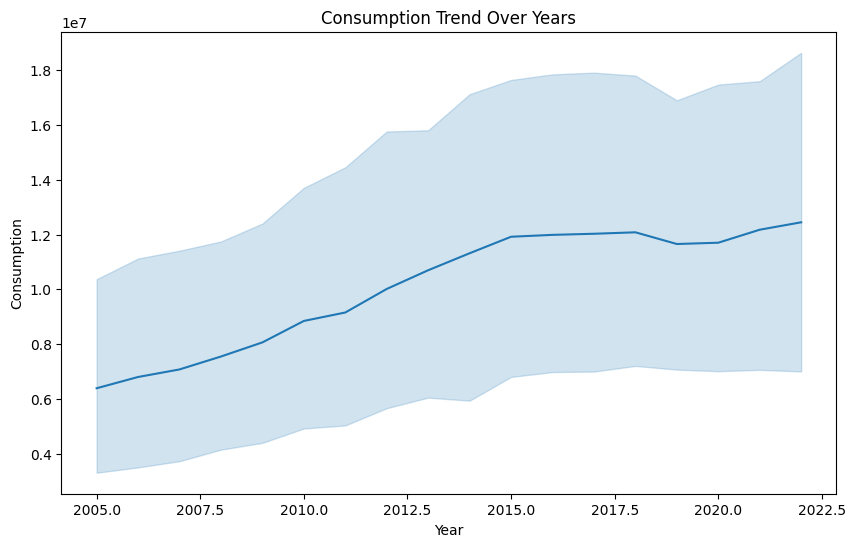

In [23]:
import matplotlib.pyplot as  plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.lineplot(data=df,x="Year",y="Consumption")
plt.title("Consumption Trend Over Years")
plt.show()

ماذا يفعل؟

يرسم خطًا يوضح ما إذا كان الاستهلاك في ازدياد أم تناقص على مر السنين.

النتيجة:

يُظهر لنا نمط الاستهلاك التاريخي، مما يساعد نموذج الانحدار على فهم العلاقة بين الزمن والكهرباء. 

----
What does it do?

It plots a line showing whether consumption has been increasing or decreasing over the years.

Result:

It shows us the historical consumption pattern, which helps the regression model understand the relationship between time and electricity.

## 5 Label Encoding

In [24]:
from sklearn.preprocessing import LabelEncoder

le_region=LabelEncoder()
le_sector=LabelEncoder()

df["Region_n"]=le_region.fit_transform(df["Region"])
df["Sector_n"]=le_sector.fit_transform(df["Sector"])

print(df[['Region', 'Region_n', 'Sector', 'Sector_n']].head())

     Region  Region_n        Sector  Sector_n
0   Western         3  Governmental         2
1  Southern         2  Governmental         2
4   Eastern         1  Agricultural         0
5   Western         3  Agricultural         0
6   Central         0        Others         4


In [25]:
sector_mapping = dict(zip(le_sector.classes_, le_sector.transform(le_sector.classes_)))
sector_mapping

{'Agricultural': 0,
 'Commercial': 1,
 'Governmental': 2,
 'Industrial': 3,
 'Others': 4,
 'Residential': 5}

ماذا يفعل؟

يعطي كل كلمة رقم فريد (مثلا: يصير الغربي 1، يصير الشرقي 2).

نتيجة:

تصير البيانات جاهزة لتدريب نماذج الـ Machine Learning.

------
What does it do?

It assigns each word a unique number (e.g., "Western " becomes 1, "Southern" becomes 2).

Result:

The data is now ready for training machine learning models.

## 6 Regression Model

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# تحديد المدخلات والمخرج
x=df[['Year', 'Region_n', 'Sector_n']]
y=df['Consumption']

# تقسيم البيانات لتدريب واختبار
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2 ,random_state=42)

# تدريب النموذج
reg_model=RandomForestRegressor()
reg_model.fit(x_train ,y_train)

print("Regression Model Trained!")

Regression Model Trained!


ماذا يفعل؟

يتعلم من البيانات التاريخية (السنة، المنطقة، القطاع) كيفية حساب أرقام الاستهلاك.

النتيجة: 
يمكنك الآن إدخال أي سنة مستقبلية وسيخبرك باستهلاك الميغاواط المتوقع.

----
What does it do?

It learns from historical data (year, region, sector) how to calculate consumption figures.

Result: 

You can now give it any future year and it will tell you the expected megawatt consumption.

## 7 Classification Model

In [27]:
from sklearn.ensemble import RandomForestClassifier

# هنا نبي نتوقع القطاع (Sector_n)
X_clf = df[['Year', 'Region_n', 'Consumption']]
y_clf = df['Sector_n']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

clf_model = RandomForestClassifier()
clf_model.fit(X_train_c, y_train_c)

print("Classification Model Trained!")


Classification Model Trained!


ماذا يفعل؟

يحاول النموذج توقع نوع القطاع مثل السكني أو التجاري أو الحكومي أو الزراعي، بناءً على السنة والمنطقة وكمية الاستهلاك.

النتيجة:

يساعد النموذج في تصنيف استهلاك الكهرباء حسب القطاع.

---
What does it do?

It tries to predict the type of sector, such as Residential, Commercial, Governmental, Industrial, Agricultural, or Others, based on Year, Region, and Consumption.

Result:

It helps classify electricity consumption by sector.

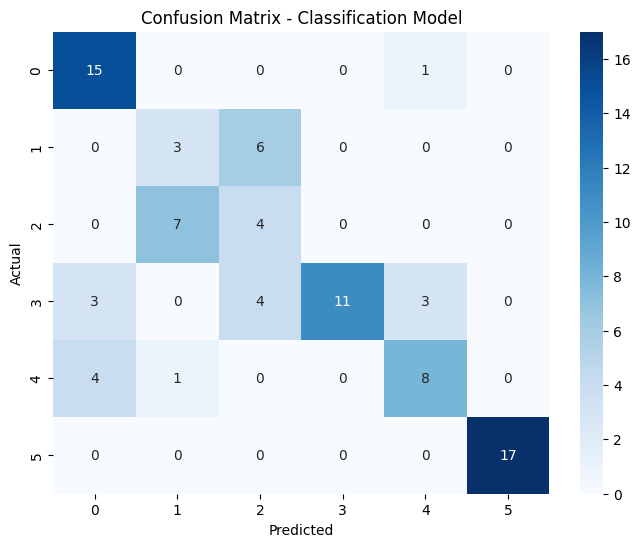

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# مصفوفة الارتباك
cm = confusion_matrix(y_test_c, clf_model.predict(X_test_c))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Classification Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8 Evaluate Regression Model
تقييم نموذج الانحدار

In [29]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. التنبؤ باستخدام بيانات الاختبار
y_pred_reg = reg_model.predict(x_test)

# 2. حساب المقاييس
mae = mean_absolute_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print(f"Mean Absolute Error: {mae:,.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 699,869.12
R2 Score: 0.99


ماذا يفعل؟

MAE: يحسب متوسط الفرق بين الرقم الحقيقي والرقم اللي توقعه النموذج.  

R2 Score: يعطينا نسبة مئوية (من 0 إلى 1) توضح مدى نجاح النموذج في فهم البيانات.  

النتيجة:

إذا كان R2 قريبًا من 1.00، فهذا يعني أن النموذج يفسر معظم الاختلافات في بيانات الاختبار. لكن لأن البيانات مرتبطة بالسنوات، فإن التقسيم الزمني يعطي تقييمًا أكثر واقعية للتنبؤ بالمستقبل.

------
What does it do?

MAE:

Calculates the average difference between the actual figure and the figure predicted by the model.

R2 Score:

Gives us a percentage (from 0 to 1) that shows how well the model interpreted the data.

Result: 

If the R2 score is close to 1.00, this means the model explains most of the variation in the test data. However, because the data is time-based, a time-based split would give a more realistic evaluation for future prediction.

## 9 Evaluate Classification Model
اختبار دقة نموذج التصنيف

In [30]:
from sklearn.metrics import accuracy_score, classification_report

# 1. التنبؤ بنوع القطاع
y_pred_clf = clf_model.predict(X_test_c)

# 2. حساب الدقة
accuracy = accuracy_score(y_test_c, y_pred_clf)

print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_c, y_pred_clf))

Accuracy Score: 66.67%

Detailed Report:
              precision    recall  f1-score   support

           0       0.68      0.94      0.79        16
           1       0.27      0.33      0.30         9
           2       0.29      0.36      0.32        11
           3       1.00      0.52      0.69        21
           4       0.67      0.62      0.64        13
           5       1.00      1.00      1.00        17

    accuracy                           0.67        87
   macro avg       0.65      0.63      0.62        87
weighted avg       0.73      0.67      0.67        87



##  10 Final Test (Manual Prediction)
الاختبار النهائي  (توقع يدوي)

Region_n
| المنطقة  | الرقم |
| -------- | ----- |  
| Central  | 0     |
| Eastern  | 1     |
| Southern | 2     |
| Western  | 3     |

Sector_n

| القطاع       | الرقم |
| ------------ | ----- |
| Agricultural | 0     |
| Commercial   | 1     |
| Governmental | 2     |
| Industrial   | 3     |
| Others       | 4     |
| Residential  | 5     |



In [31]:
import pandas as pd

sample = pd.DataFrame([[2026, 0, 0]], columns=['Year', 'Region_n', 'Sector_n'])

sample_pred = reg_model.predict(sample)

print(f"Predicted Consumption for : {sample_pred[0]:,.2f} MWh")

Predicted Consumption for : 3,420,378.74 MWh


In [36]:
import pandas as pd

sample = pd.DataFrame([[2026, 0, 3420378]], 
                       columns=['Year', 'Region_n', 'Consumption'])

pred = clf_model.predict(sample)

sector_name = le_sector.inverse_transform(pred)

print(f"Predicted Sector_n = {pred[0]}")
print(f"Predicted Sector = {sector_name[0]}")

Predicted Sector_n = 0
Predicted Sector = Agricultural
